In [1]:
%%file loopback_arb.py

import numpy as np
import matplotlib.pyplot as plt


from acadia.runtime import Runtime
from acadia.data import DataManager, ArrayRecordGroup

class PlotRecordGroup(ArrayRecordGroup):
    
    def initialize_display(self):
        from itertools import count
        import matplotlib.pyplot as plt
        from matplotlib.animation import Animation
        # plt.ion()
        
        # fig,ax = plt.subplots(figsize=(8,4))
        # (line_re,) = ax.plot([], [], animated=True)
        # (line_im,) = ax.plot([], [], animated=True)
        # ax.set_ylim(-0.01, 0.01)
        # ax.set_xlim(0,5)
        # ax.grid()
        # fig.show()
        # plt.pause(0.1)
        
        # print(type(fig.canvas.manager))
        
        
        # bg = fig.canvas.copy_from_bbox(fig.bbox)
        
        # ax.draw_artist(line_re)
        # ax.draw_artist(line_im)
        # fig.canvas.blit(fig.bbox)
        # # fig.canvas.flush_events()
                
        # self.fig = fig
        # self.ax = ax
        # self.bg = bg
        # self.line_re = line_re
        # self.line_im = line_im
        
        # return None
        
        fig,ax = plt.subplots(figsize=(8,4))
        (line_re,) = ax.plot([], [], animated=False)
        (line_im,) = ax.plot([], [], animated=False)
        ax.set_ylim(-0.01, 0.01)
        ax.set_xlim(0,5)
        ax.grid()
        
        def init(self, *args, **kwargs):
            self._framedata = count()
            super(self.__class__, self).__init__(*args, **kwargs)
            
        def draw_frame(anim_self, framedata):
            if self.records() is not None:
                # Just plot only the most recently received trace
                axis = self.axis()*1e6
                trace = self.records()[-1,:]
                
                # fig,ax,bg,line_re,line_im = self.fig,self.ax,self.bg,self.line_re,self.line_im
                # line_re,line_im = self.line_re,self.line_im
                # fig.canvas.restore_region(bg)
                
                # Prepare the background
                line_re.set_data(axis, np.real(trace))
                line_im.set_data(axis, np.imag(trace))
        
        test_animation_type = type("TestAnimation", (Animation, ), {"__init__": init, "_draw_frame": draw_frame})

        def _dummy(*args, **kwargs):
            pass

        self._anim = test_animation_type(fig, event_source=type("_DummyEvent", (), {"add_callback": _dummy, "start": _dummy, "stop": _dummy}))

        return self._anim
    
    def update_display(self, args):   
        
        # ax.set_title(str( frame))
        
        self._anim._step()
        
        # return line_re, line_im
        
class LoopbackArbRuntime(Runtime):
    
    @classmethod
    def main(cls, directory: str , datamanager: DataManager):
        import time
        import numpy as np
        
        from acadia.system import Acadia, StreamConfiguration
        from acadia.channel import Channel
        from acadia.arrays import ProceduralWaveform
        from acadia.data import DataManager, ArrayRecordGroup
        
        acadia = Acadia()

        pulse_channel = acadia.DAC(1)

        def pulse_shape(out, sample_times):
            out[:] = Channel.to_samples(0.99*np.ones(len(sample_times), dtype=np.complex64))

        pulse = ProceduralWaveform(pulse_channel, generator=pulse_shape, region=pulse_channel)

        capture_channel = acadia.ADC(1)
        capture_data = ProceduralWaveform(capture_channel, generator=None, length=5000e-9, region=acadia.PLDDR0Array)
        capture_configuration = StreamConfiguration(capture_channel, acadia=acadia)            
                        
        # We'll collect the data traces in a record group
        traces = PlotRecordGroup("traces", record_axes=[capture_data.axis()])
            
        # Make a data manager for storing data and serving it to a plotter
        datamanager.add_group(traces)
        
        # Create a sequence for the sequencer
        def sequence(a):
            capture_configuration.reset()
            for i in range(100):
                a._active_sequencer.nop()
            
            with a.channel_synchronizer(block=False):
                a.capture(capture_configuration, capture_data)
                a.generate(pulse)
                a.generate(pulse)
                a.generate(pulse)
                
            # pulses = a.sequencer().DSP()
            # pulses.load(3)
                
            # with a.sequencer().repeat_until(pulses == 5):
            #     with a.sequencer().test(a.all_channel_fifos_empty(pulse_channel)):
            #         with a.channel_synchronizer(trigger=False, block=False):
            #             a.generate(pulse)
            #         pulses += 1

        # Because the pulse is procedurally generated, we can change its length at runtime,
        # so we need to start by allocating the length to use initially
        pulse.allocate(500e-9)

        # Attach to the hardware
        acadia.attach()

        # Load the wave memory with the pulse by calling the generator function
        pulse.populate()

        # Configure channel parameters
        pulse_channel.set_nyquist_zone(2)
        pulse_channel.configure_nco(frequency=2000e6)
        pulse_channel.set_vop(20000)
        
        capture_channel.set_nyquist_zone(2)
        capture_channel.set_dsa(0)

        # Configure the stream processing path to capture data using the configuration
        # written above
        acadia.configure_stream(capture_configuration)

        # Compile only once
        acadia.compile(sequence)
                
        for shot in datamanager.report_iterations(range(1000)):
            acadia.run(assemble=(shot==0))
            
            # Get the trace data and write it into a record
            trace = Channel.from_samples(capture_data.memory())
            datamanager.append("traces", trace)
            
            # # Wait some time until running again just so that we can see the plot update
            # time.sleep(0.001)

Overwriting loopback_arb.py


Button(description='Stop', style=ButtonStyle(), tooltip='Click to stop all local and remote processes.')

  0%|          | 0/1000 [00:00<?, ?it/s]

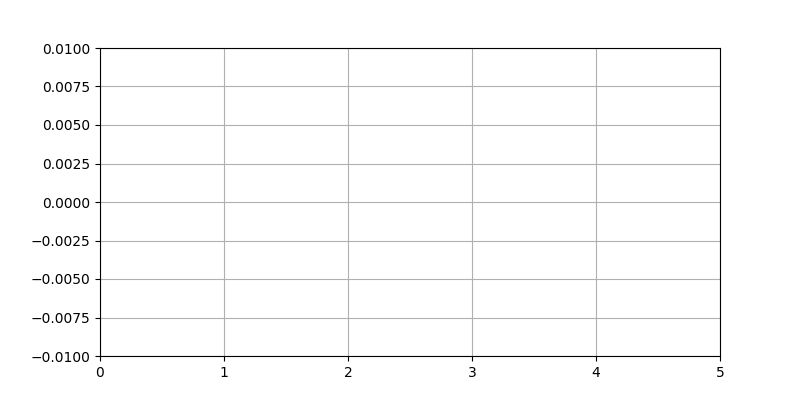

In [3]:
%matplotlib widget
from loopback_arb import LoopbackArbRuntime
import logging
logging.basicConfig(level=logging.DEBUG, 
                    filename="/home/billy/runtime.log", 
                    filemode="w",
                    format='[%(asctime)s] %(levelname)s at %(funcName)s (%(filename)s, %(lineno)d): %(message)s')
rt = LoopbackArbRuntime()
rt.run("loopback_arb.py", "192.168.2.69")

In [ ]:
%matplotlib widget

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig,ax = plt.subplots(figsize=(8,4))
(line_re,) = ax.plot([], [], animated=False)
(line_im,) = ax.plot([], [], animated=False)
ax.set_ylim(-1, 1)
ax.set_xlim(0,1)
ax.grid()

tstart = time.time()

def update(*args):
    axis = np.linspace(0,1,1001)
    trace = np.sin(2*np.pi*axis + 2*(time.time()-tstart))
    line_re.set_data(axis, np.real(trace))
    line_im.set_data(axis, np.imag(trace))
    return line_re,line_im

anim = FuncAnimation(fig, update, interval=10, blit=False)

In [ ]:
%matplotlib widget

import numpy as np
from itertools import count
import matplotlib.pyplot as plt
from matplotlib.animation import Animation

fig,ax = plt.subplots(figsize=(8,4))
(line_re,) = ax.plot([], [], animated=False)
(line_im,) = ax.plot([], [], animated=False)
ax.set_ylim(-1, 1)
ax.set_xlim(0,1)
ax.grid()

def init(self, *args, **kwargs):
    self._framedata = count()
    super(self.__class__, self).__init__(*args, **kwargs)
    
def draw_frame(self, framedata):
    axis = np.linspace(0,1,1001)
    trace = np.sin(2*np.pi*axis + 0.1*framedata)
    line_re.set_data(axis, np.real(trace))
    line_im.set_data(axis, np.imag(trace))
        
test_animation_type = type("TestAnimation", (Animation, ), {"__init__": init, "_draw_frame": draw_frame})


anim = test_animation_type(fig, event_source=fig.canvas.new_timer(interval=100))

In [ ]:
%matplotlib widget

import numpy as np
from itertools import count
import matplotlib.pyplot as plt
from matplotlib.animation import Animation

fig,ax = plt.subplots(figsize=(8,4))
(line_re,) = ax.plot([], [], animated=False)
(line_im,) = ax.plot([], [], animated=False)
ax.set_ylim(-1, 1)
ax.set_xlim(0,1)
ax.grid()

def init(self, *args, **kwargs):
    self._framedata = count()
    super(self.__class__, self).__init__(*args, **kwargs)
    
def draw_frame(self, framedata):
    axis = np.linspace(0,1,1001)
    trace = np.sin(2*np.pi*axis + 0.1*framedata)
    line_re.set_data(axis, np.real(trace))
    line_im.set_data(axis, np.imag(trace))
        
test_animation_type = type("TestAnimation", (Animation, ), {"__init__": init, "_draw_frame": draw_frame})

def _dummy(*args, **kwargs):
    pass

anim = test_animation_type(fig, event_source=type("_DummyEvent", (), {"add_callback": _dummy, "start": _dummy, "stop": _dummy}))

def _target():
    import time
    for i in range(50):
        anim._step()
        time.sleep(0.02)

from threading import Thread
thread = Thread(target=_target)
thread.start()

In [ ]:
%matplotlib widget

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig,ax = plt.subplots(figsize=(8,4))
(line_re,) = ax.plot([], [], animated=False)
(line_im,) = ax.plot([], [], animated=False)
ax.set_ylim(-1, 1)
ax.set_xlim(0,1)
ax.grid()
plt.show(block=False)
fig.canvas.draw_idle()
fig.canvas.flush_events()

tstart = time.time()

def update(*args):
    axis = np.linspace(0,1,1001)
    trace = np.sin(2*np.pi*axis + 2*(time.time()-tstart))
    line_re.set_data(axis, np.real(trace))
    line_im.set_data(axis, np.imag(trace))
    return line_re,line_im

for i in range(500):
    update()
    fig.canvas.draw_idle()
    fig.canvas.flush_events()
    time.sleep(0.01)